In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver


In [4]:
load_dotenv()

True

In [5]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

In [6]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):
    #take user query from state
    messages = state['messages']
    #send to llm
    response = llm.invoke(messages)
    #response store state
    return {'messages': [response]}

In [14]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)

#add nodes
graph.add_node('chat_node',chat_node)

#add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpoint)

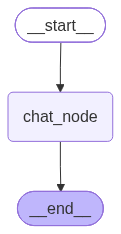

In [15]:
chatbot

In [34]:
thread_id = "2"
initial_state = {
    'messages':[HumanMessage(content="what is my name?")]
    }
config = {'configurable': {'thread_id': thread_id}}
response = chatbot.invoke(initial_state,config=config)

In [35]:
response['messages'][-1].content

[{'type': 'text',
  'text': 'Your name is still Alex! 😊',
  'extras': {'signature': 'EpoGCpcGAWkUfRPfXJvoBhfLK5XNrnZW3rNJu0S9/HC3AIvTTadMYqC4jdEH68iXH0gQitHOb9S3VjouIBZA0FdhYThw4uNlOgj8IWMmfE5tg7v1cBoIM2JAut1Yv5B5MUcohfdTkZP0Qn16wMTErq0a8ImmxTJGbDHNQaxszd7KIW8d1t8ywBmwOxzcA/qIvnRAQwbvyqBgBOi80yvbXTZRSV6SDWyEbfDNuhpk8YKV1u0Rnm1ZGqf+RaBvgEY6Ie+lgmc6IwtPfSBNaYM43BomkbUzf0jYqI83QNxC2ftbegS5UsnNivZ0icDULLpLAzdgHKRTc4mjfytwnSY1+hZrwidkz4acU9mOFnkR3WSDLSD+taufT+vgDuVan5nPFziKQ/0rylyWmCld3y7AstQEzDetMWHH/hai1CgcAOKKKGYvpxyamHQ8g6iwKy7xs30bEirokWLXXKPN0XFKmUccTPmrVPuN0zMwlX/lo3sQ9AP8QMbnmPAZQRaImKOgV+Z7tRqH0abUa9fIxlJAoXaCS+nVuLvnFQs1bWO/CFdJovTe1suMCSGFhNsjrxoTs3ufVdeYNS4pVuLvrkhu7/z2w2lZm49968RWv6rIPtjUGhd2fPS4QpSYKLyQ8/h6eELWeBiLt+CX1lNLV39ckKRfKd5UNi71y/FdxS14FsNnf0GQngiSByJs1WeITlZypu0y5rxXJgK5FZAjfimiNUJviFxM/MMCmi4YyrA6tqwmA55fJz0TTW37ssWHPdHDS/+sjaCynUYCcmFv1U79dbJ0zaFxR/Ot4ZwTHth9GZaCu8U2KRtABFONeefxsSqYOFT2+aDJxdjomfxwrIeV2THVDrozvhc+RjKpjdm9smUCzuVriKdj8N2gIOj2Mmn+Wuw9aanWSfYw1+mlhil

In [21]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hii my name is alex', additional_kwargs={}, response_metadata={}, id='c57ee2c6-9227-48cd-ad88-c532ebd3fd0e'), AIMessage(content=[{'type': 'text', 'text': "Hi Alex! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EtgECtUEAWkUfRPfmoC021tHNHU4X3bqQDuRVFw+dA2sNhEFciPH+mdw/BIb5qgnO/9DNIfek+oDE+zOXGAp8Z69I2WWuwl+ZInvbTK6u+axot9WLDqQ4WlzsLIG81PYm5X1BDxTm6LP1yLdENAmKc30ZtBOeCCU4c0sHCDB0FhjCS6FgKlBrSTP36mmmeItFmxyvTB8gd2Bh+RH4F3eMkltMginXEy6ROKTAaQLuBhCxTew2av87MaAlKjrh33qcGP8EWlQQrq8OHzVCG20BQ8fyzC9EmksVDXcZpN6yqGiTZEK0VyuPhkXwahMVanboLTg7Q5zfrdUrBprwMXi19QBtb3MkazQOId68lePEMbPzqapp6nH2XIMLWoNr8SL2jsWjWlLMqfaYdejx56ttpQHZWbvLjovOUMSEsB61CAaYWNiq1+HRjxQpJBcl72AnNhXzB3FIemIm61QktiV1i2TS9HqiE1feCVa1AhpRuoQzUyNCGMc+cpOOZyQIxr8YqIJ6pFXU3ThqqCm2WRceHqHbNVNoR/t2q+rRcL9+VqVjGZhXPJqcHT8RQEu7+wHyvpF9krH07B7bilRufkyCB8kbK9EcVZmdBsbMrogiuuGuQx/7aERmilBeCYo4UOJmFat/b/iTjgdK18Ls+JdIk2o2Pap489D26THhipEGNWY80XelCJ2ZcdAeIMeGO

In [29]:
thread_id = "1"

while True:
    user_message = input('Type here:')

    print('User:', user_message)

    if user_message.lower().strip() in ['exit', 'quit', 'bye']:
        print('Exiting the chatbot.')
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
    print('AI:', response['messages'][-1].content)

User: my name is amer
AI: [{'type': 'text', 'text': "Yes, you are Amer! 😄 \n\nWhenever you're ready, let me know what you'd like to work on or learn next!", 'extras': {'signature': 'EtYECtMEAWkUfRMmN6HuWsE/muGr52k1BTVHbWqBC79KU1g1oXI9q5FdF7qtB9RpTtArjXlsoKVzbeaMRmvEXFyIAN9l4JHFewb2v7ErOujhIqBHy2UwxXuRaDBXVaDOLlGQfPmOV0IPfT6RdUn8wDm02LsAgr4hifBvWUR4rEXxCtei1lqJu/AB1pVE9O1MoMJV58pAfm56Oh/v6z7ilzZykQCGrgdumzt3tvCU+sPaZfAUhPJnm1eCXJxVX5q9Eb7UhShTNebVhCU+GIFs8tsQSKB2LlDWviFEXk+BHE2EiGmvcFL6mVl9IfzfulyovrE4AHuPtb8XpE8HRDixOHulooTJMtIZYfw+zCgbtHVSmo731HWRJOeD0jD7NclkN0NTdHm4aEfPnUH6w0LW/CmzbnskrwpIZuGwbrOStJxhw/F6ic6LEf7VwHL/nmggHmdHKwR8G3fXUYFYPSypZ2fMuV9cJB8Sw1TEmslgDmxTFnLgayNrAlKmCir8oiy/DyRXOkaUjclHMTQbB2fGWhOgzY7bWGMWY3k9oYLSnhCrhpIokYTTd3FdBzfMyU+28Cd5gypPQAwwxWizqK4v7fPpl5kSj24QXOm9GmhdxaBJ1nXXN8nvJyhB2O1enuBCbFiOo1o19xXP+SMuZnzneC4MbHUYSUwlnGZGebokGmFEHXBxkXCutIsqGaI8XNOvzmTMGdig4zcL8g2mu0Kd25+Yn4i1AC/77zGAxA71Dr1V+FicIzK/0hyrZlsNTFvDDpaHkpL6rJwoe+3GQ2y7Qzh6Bb5dkG4Kuw=='}}]
User: exi